# Patch labels viz

In this notebook, we will quickly visualize the labels associated with random patches for all the 3 set used during the training of our models.

In [1]:
# Boilerplate code to automatically reload imports and to have
# access to the project sourcecode.
%load_ext autoreload
%autoreload 2
    
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.io import PATCHES_DIR, PATCHES_METADATA, MULTISEASONAL_SCENE
import pathlib
import random
import math
import json
import rasterio

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

In [3]:
BACKGROUND_HEX = "#1a1a1a"
BACKGROUND_RGB = (0, 0, 0)

## Block grid visualization

In [20]:
with open(PATCHES_METADATA, "r") as json_file:
    file = json.load(json_file)
    grid_mask = np.array(file["keep_mask"])
    sets_mask = np.array(file["block_labels"])

We can see into how many blocks we divided the raster:

In [21]:
grid_mask.shape

(20, 20)

In [22]:
sets_mask.shape

(5, 5)

In [23]:
pixel_mask = np.repeat(np.repeat(grid_mask, 256, axis=0), 256, axis=1)
pixel_mask_buffer = np.where(pixel_mask != 1, pixel_mask, np.nan)

pixel_sets = np.repeat(np.repeat(sets_mask, 4 * 256, axis=0), 4 * 256, axis=1)

In [24]:
pixel_sets.shape, pixel_mask.shape

((5120, 5120), (5120, 5120))

In [25]:
rgb_indexes = np.array([1, 2, 3])

with rasterio.open(MULTISEASONAL_SCENE, "r") as  src:
    rgb_raster = src.read(rgb_indexes.tolist())

Let's do some pre-processing of the raster before the visualization:

In [26]:
rgb.shape

(5120, 5120, 3)

In [27]:
dim_transposition = (1, 2, 0)
rgb = np.transpose(rgb_raster, dim_transposition)
rgb = rgb [:, :, ::-1]
rgb = rgb * 0.0001 - 0.1
p2, p98 = np.nanpercentile(rgb, [2, 98])
rgb = np.clip((rgb - p2)/ (p98 - p2), 0, 1)

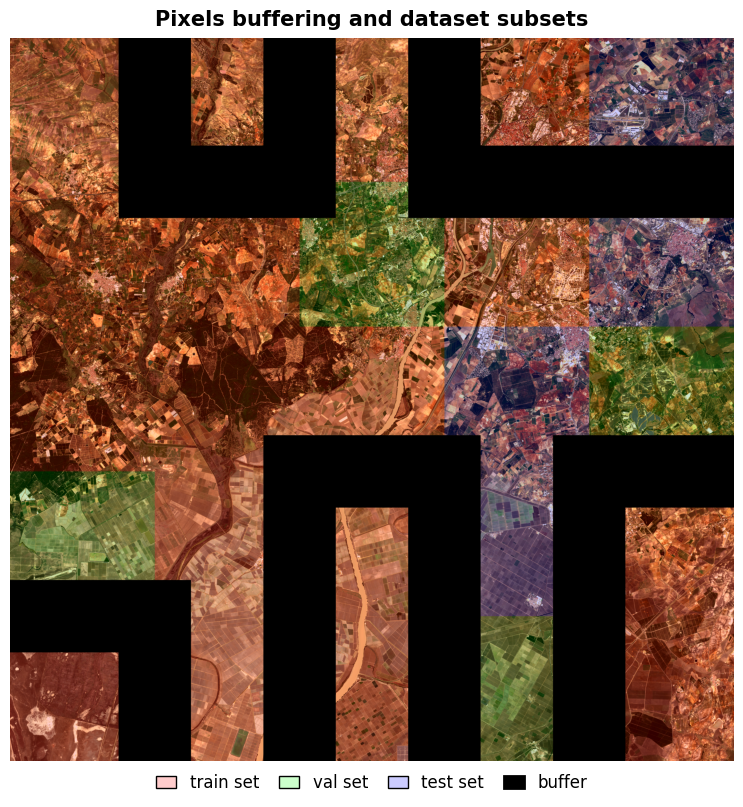

In [53]:
fig, ax = plt.subplots(figsize=(8, 8), layout='constrained')
_ = ax.imshow(rgb, alpha=1)

colors = ['red', "blue", "green"]
cmap = mcolors.ListedColormap(colors)
ax.imshow(pixel_sets, cmap=cmap, alpha=0.2)

overlay = np.zeros((*pixel_mask_buffer.shape, 4))   # RGBA, all zeros = black, alpha=0
is_zero = pixel_mask_buffer == 0
overlay[..., 3] = np.where(is_zero, 1.0, 0.0)     
ax.imshow(overlay)
patches = [
    mpatches.Patch(facecolor=(1, 0, 0, 0.2), label="train set", edgecolor='black', linewidth=1),
    mpatches.Patch(facecolor=(0, 1, 0, 0.2), label="val set", edgecolor='black', linewidth=1),
    mpatches.Patch(facecolor=(0, 0, 1, 0.2), label="test set", edgecolor='black', linewidth=1),
    mpatches.Patch(facecolor="black",label="buffer", edgecolor='black', linewidth=2)
]
fig.legend(
    loc='outside lower center',
    handles=patches,
    frameon=False,
    fontsize=12,
    ncols=4,
    handlelength=1.2,
    columnspacing=1.2,
)
fig.suptitle(
    f"Pixels buffering and dataset subsets",
    fontsize=15,
    fontweight="bold",
)

_ = ax.axis("off")

## Labels patches visualization

In [71]:
train_path = PATCHES_DIR / "train"
val_path = PATCHES_DIR / "val"
test_path = PATCHES_DIR / "test"

N_COLS = 8
N_ROWS = 8
N_SAMPLES = N_COLS * N_ROWS

In [72]:
type(train_path)

pathlib.PosixPath

In [73]:
def get_set_labels_sample(sample_path: pathlib.PosixPath, n_samples: int):
    sample = list(sample_path.glob("*label.npy"))
    return random.sample(sample, n_samples)

def features_from_labels_path(labels_path: list[pathlib.PosixPath]) -> list[pathlib.PosixPath]:
    return [pathlib.Path(str(p).replace("_label.npy", "_feature.npy")) for p in labels_path]

In [74]:
samples_labels_train = get_set_labels_sample(train_path, N_SAMPLES)
samples_features_train = features_from_labels_path(samples_labels_train)

In [75]:
samples_features_train[:3]

[PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0183_feature.npy'),
 PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0089_feature.npy'),
 PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0011_feature.npy')]

In [76]:
samples_labels_train[:3]

[PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0183_label.npy'),
 PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0089_label.npy'),
 PosixPath('/Users/stepit/Repositories/projects/lulc-classification/data/patches/train/patch_0011_label.npy')]

In [136]:
def normalize_rgb(rgb):
    return tuple([x / 255 for x in rgb])

WORLDCOVER_CLASSES = {
    0: ("No Data", (255, 255, 255)),
    1: ("Tree cover", (0,100,0)),
    2: ("Shrubland", (255, 187, 34)),
    3: ("Grassland", (255, 255, 76)),
    4: ("Cropland", (240, 150, 255)),
    5: ("Build-up", (250, 0, 0)),
    6: ("Bare/sparse vegetation", (180, 180, 180)),
    7: ("Snow and ice", (240, 240, 240)),
    8: ("Permanent water bodies", (0, 100, 200)),
    9: ("Herbaceous wetland", (0, 150, 160)),
    10: ("Mangroves", (0, 207, 117)),
    11: ("Moss and lichen", (250, 230, 160)),
}

n = len(WORLDCOVER_CLASSES.items())
colors = [normalize_rgb(WORLDCOVER_CLASSES.get(i, ("", (0, 0, 0)))[1]) for i in range(n)]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries=range(n + 1), ncolors=n)
patches = [
    mpatches.Patch(facecolor=normalize_rgb(color), label=f"{_label}", edgecolor='black', linewidth=2) for (_label, color) in WORLDCOVER_CLASSES.values()
]

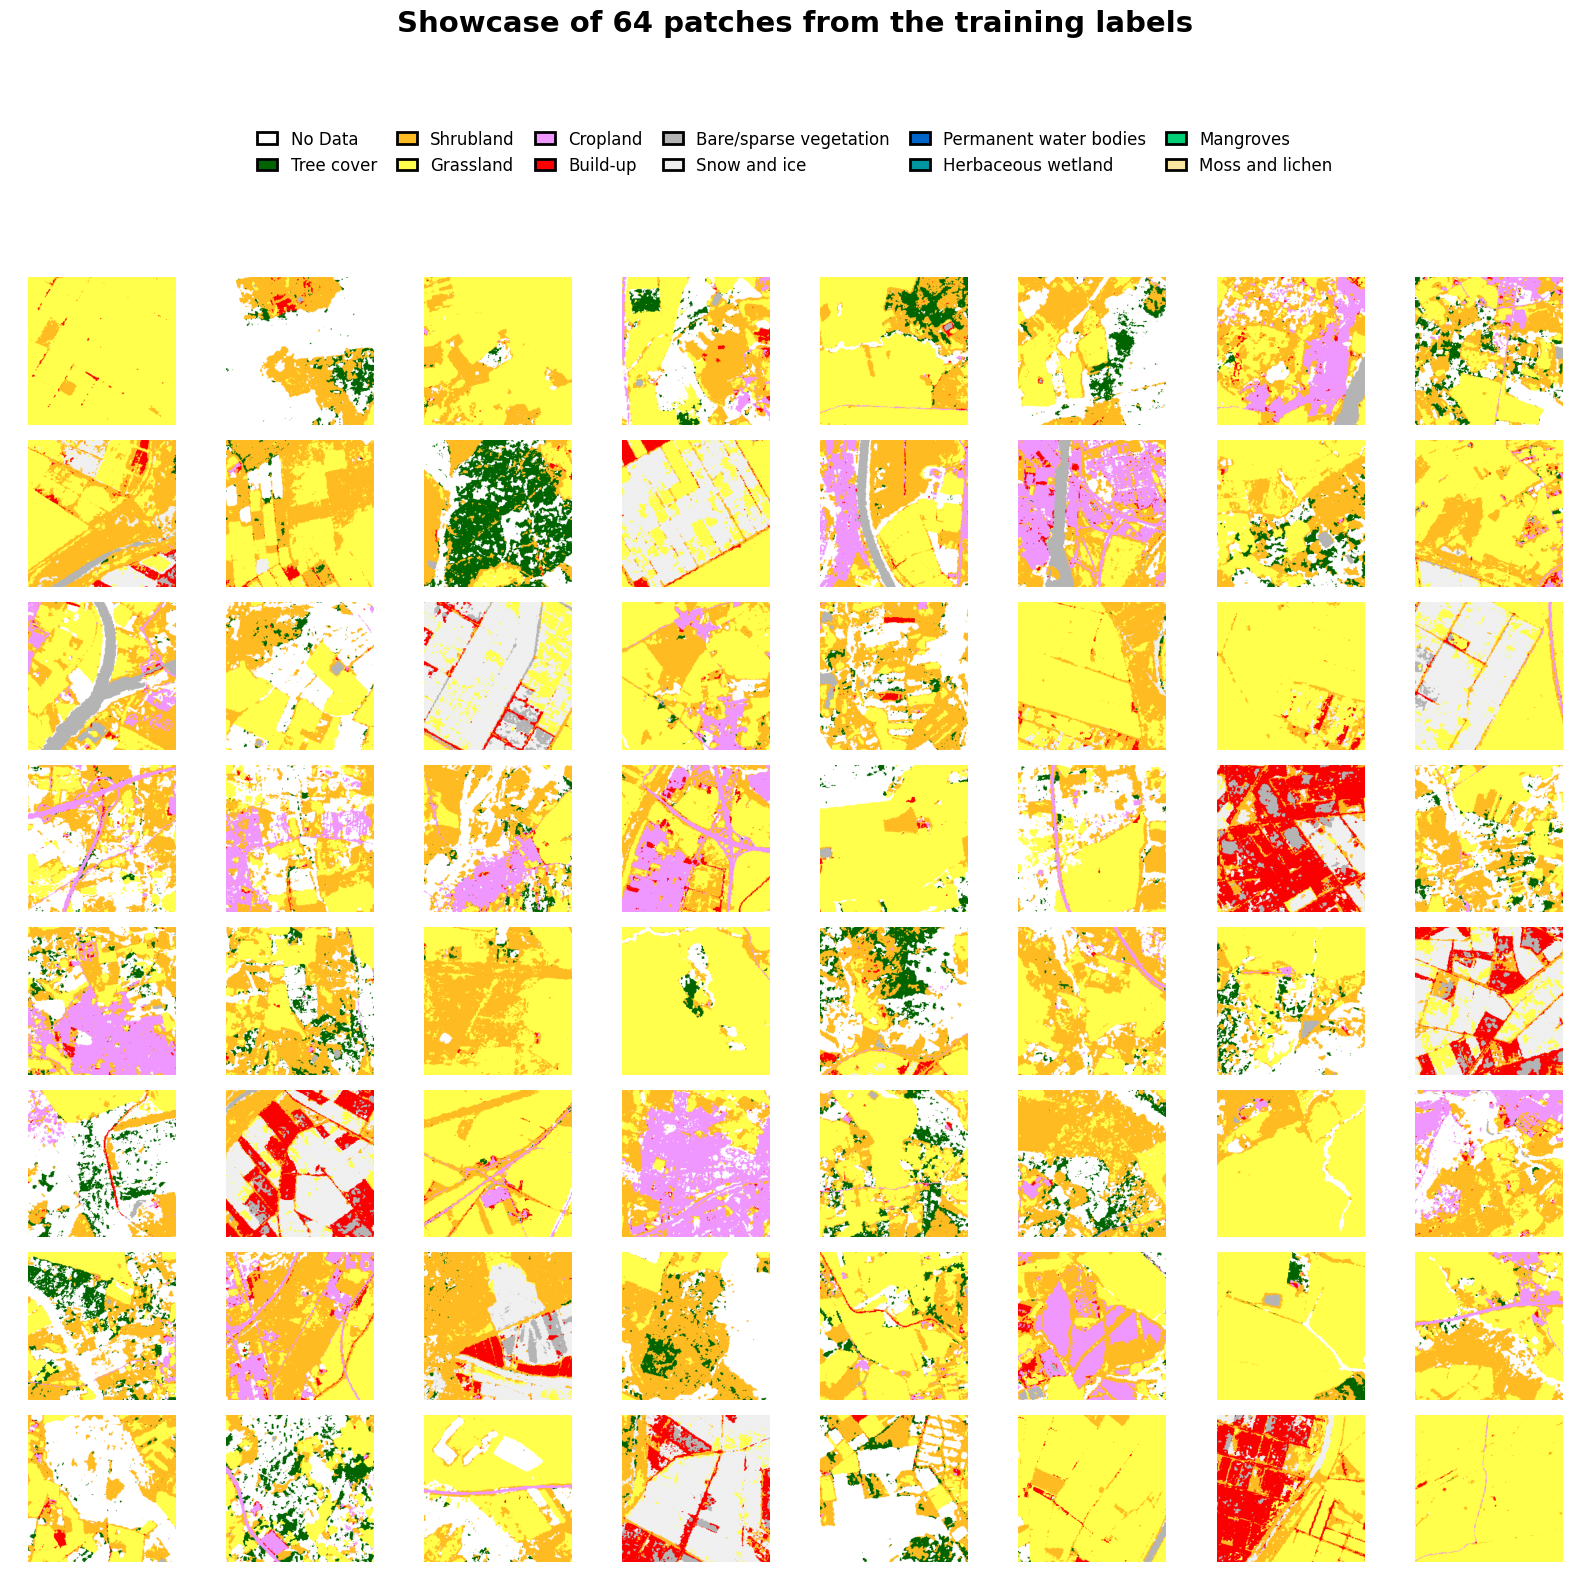

In [137]:
fig, ax = plt.subplots(
    ncols=N_COLS, 
    nrows=N_ROWS + 1, 
    figsize=(4 * 4, 2 * N_ROWS),
    gridspec_kw = {"height_ratios": [2] + [2] * N_ROWS},
    
)

for a in ax[0]:
    a.remove()
legend_ax = fig.add_subplot(N_ROWS + 1, 1, 1)
legend_ax.axis("off")
legend_ax.legend(
    handles=patches,
    loc="upper center",
    ncol=n / 2,
    frameon=False,
    fontsize=12,
    handlelength=1.2,
    columnspacing=1.2,
)

ax = ax[1:].flatten()
for index, patch_path in enumerate(samples_labels_train):
    raster = np.load(patch_path)
    ax[index].imshow(raster, cmap=cmap, norm=norm)
    ax[index].axis("off")

# Suppress the output that is not removed with formatting.
_ = fig.suptitle(
    f"Showcase of {N_SAMPLES} patches from the training labels",
    fontsize=21,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.95])